/Users/shunkhwn/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


🚀 Initializing Bit Wave Evaluation Engine...
📦 Loading Neural Weights...
🧠 Performing Batch Inference...


/Users/shunkhwn/Library/Python/3.9/lib/python/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



═════════════════════════════════════════════
  BASELINE ACCURACY:  85.50%
  OPTIMIZED ACCURACY: 89.19%
═════════════════════════════════════════════

🔍 OPTIMIZED MODEL PERFORMANCE REPORT
               precision    recall  f1-score   support

   Electronic       0.93      0.88      0.91       205
 Experimental       0.85      0.91      0.88       200
         Folk       0.95      0.88      0.91       185
      Hip-Hop       0.87      0.94      0.90       206
 Instrumental       0.85      0.89      0.87       204
International       0.90      0.90      0.90       211
          Pop       0.92      0.83      0.87       202
         Rock       0.88      0.91      0.90       187

     accuracy                           0.89      1600
    macro avg       0.89      0.89      0.89      1600
 weighted avg       0.89      0.89      0.89      1600



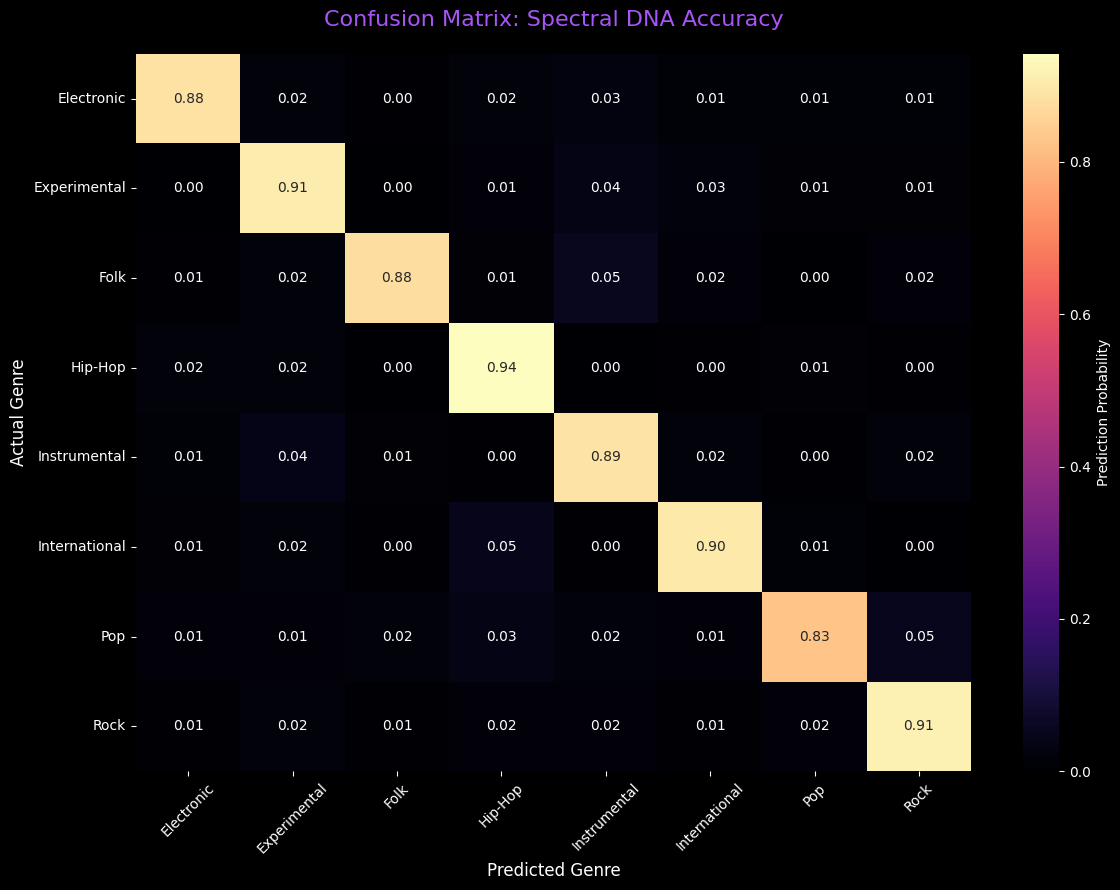

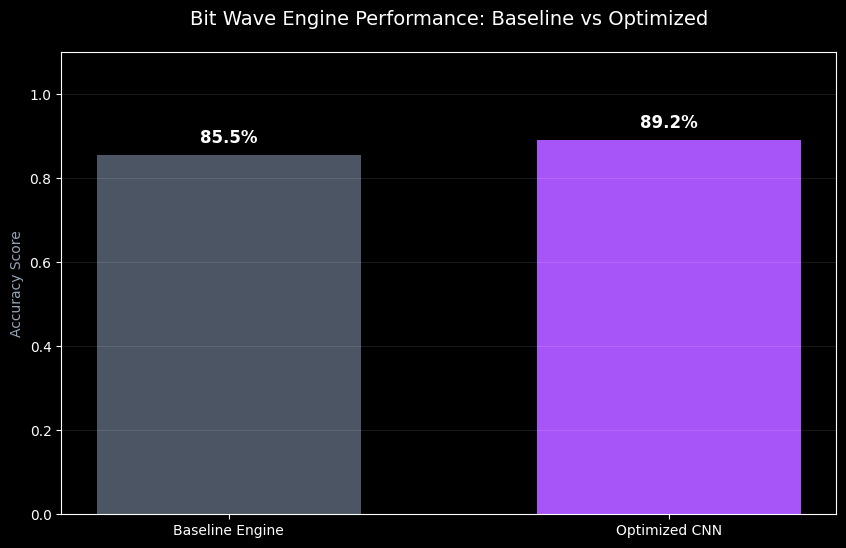

In [ ]:
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
import tensorflow as tf

# 1. Configuration & Data Loading
DATA_PATH = "data.json" 
BASELINE_PATH = "baseline_model.h5"
OPTIMIZED_PATH = "optimized_model.h5"

print("🚀 Initializing Bit Wave Evaluation Engine...")
with open(DATA_PATH, "r") as fp:
    data = json.load(fp)

# X shape is typically (samples, frames, mfcc, 1)
X = np.array(data["mfcc"])[..., np.newaxis]
y = np.array(data["labels"])
mapping = data["mapping"]

# 2. Split into Train/Test (Consistent with training state)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Load Models
print("📦 Loading Neural Weights...")
baseline = tf.keras.models.load_model(BASELINE_PATH, compile=False)
optimized = tf.keras.models.load_model(OPTIMIZED_PATH, compile=False)

# 4. Generate Predictions
print("🧠 Performing Batch Inference...")
prob_opt = optimized.predict(X_test, verbose=0)
prob_base = baseline.predict(X_test, verbose=0)

y_pred_opt = np.argmax(prob_opt, axis=1)
y_pred_base = np.argmax(prob_base, axis=1)

# 5. Accuracy Comparison
acc_base = accuracy_score(y_test, y_pred_base)
acc_opt = accuracy_score(y_test, y_pred_opt)

print("\n" + "═"*45)
print(f"  BASELINE ACCURACY:  {acc_base*100:.2f}%")
print(f"  OPTIMIZED ACCURACY: {acc_opt*100:.2f}%")
print("═"*45)

# 6. Detailed Classification Report
print("\n🔍 OPTIMIZED MODEL PERFORMANCE REPORT")
unique_labels = np.unique(y_test)
target_names = [mapping[i] for i in unique_labels]

print(classification_report(y_test, y_pred_opt, labels=unique_labels, target_names=target_names))

# 7. Visualizing the Confusion Matrix 
plt.style.use('dark_background') 
plt.figure(figsize=(12, 9))

cm = confusion_matrix(y_test, y_pred_opt, labels=unique_labels)
# Normalize CM to see percentages
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='magma', 
            xticklabels=target_names, yticklabels=target_names,
            cbar_kws={'label': 'Prediction Probability'})

plt.title("Confusion Matrix: Spectral DNA Accuracy", fontsize=16, pad=20, color='#a855f7')
plt.ylabel('Actual Genre', fontsize=12)
plt.xlabel('Predicted Genre', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 8. Comparison Bar Chart
plt.figure(figsize=(10, 6))
colors = ['#4b5563', '#a855f7'] 
bars = plt.bar(['Baseline Engine', 'Optimized CNN'], [acc_base, acc_opt], color=colors, width=0.6)

plt.ylabel('Accuracy Score', fontsize=10, color='#94a3b8')
plt.title('Bit Wave Engine Performance: Baseline vs Optimized', fontsize=14, pad=20)
plt.ylim(0, 1.1)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height*100:.1f}%', ha='center', va='bottom', 
             fontweight='bold', color='white', fontsize=12)

plt.grid(axis='y', alpha=0.1)
plt.show()